### 实验02：重复性测试

#### 实验内容
1. 多次加载-卸载循环测试
2. 重复性误差计算（相对标准偏差RSD）
3. 零点漂移分析
4. 满量程输出稳定性分析

#### 输入数据说明
- 文件格式：CSV，三列数据（Time_ms, RawValue, RawGround）
- 文件夹结构：主路径下包含 0N, 1N, ..., 7N 子文件夹
- 每个子文件夹包含多个重复测量的CSV文件
- 支持通过宏注释选择导入哪些力值文件夹

#### 1. 导入库与参数配置

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os, glob, re, sys

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
from plot_style import apply_measurement_style, COLORS, add_subplot_label, save_figure, SAVE_DIRS

apply_measurement_style()
SAVE_DIR = SAVE_DIRS[2]

FS = 200
V_REF = 5.0
LSB = V_REF / (2**15)
NOISE_STD = 1.16

#### 2. 数据加载函数

In [3]:
def load_sensor_data(file_path):
    """加载传感器CSV数据"""
    df = pd.read_csv(file_path)
    df.columns = ['Time_ms', 'RawValue', 'RawGround']
    df['Time_s'] = df['Time_ms'] / 1000
    return df

def extract_stable_mean(df, start_ratio=0.2, end_ratio=0.8):
    """提取稳定区间的均值"""
    n = len(df)
    start_idx = int(n * start_ratio)
    end_idx = int(n * end_ratio)
    stable_data = df['RawValue'].iloc[start_idx:end_idx]
    return np.mean(stable_data), np.std(stable_data)

def get_csv_files_in_folder(folder_path):
    """获取文件夹内所有CSV文件，按时间戳排序"""
    pattern = os.path.join(folder_path, "*.csv")
    files = glob.glob(pattern)
    # 按文件名排序（文件名包含时间戳）
    files.sort()
    return files

def parse_force_from_folder_name(folder_name):
    """从文件夹名称解析力值，如 '0N' -> 0.0, '7N' -> 7.0"""
    match = re.match(r'(\d+(?:\.\d+)?)N?', folder_name, re.IGNORECASE)
    if match:
        return float(match.group(1))
    return None

#### 3. 配置数据路径与导入选项

In [4]:
_BASE = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "..", "workspace", "test2")
BASE_PATH = _BASE

ENABLED_FORCES = ["0N","1N","2N","3N","4N","5N","6N","7N","8N","9N","10N"]

print(f"主路径: {BASE_PATH}")
print(f"选择的力值文件夹: {ENABLED_FORCES}")

主路径: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\02_Repeatability\..\..\workspace\test2
选择的力值文件夹: ['0N', '1N', '2N', '3N', '4N', '5N', '6N', '7N', '8N', '9N', '10N']


#### 4. 自动扫描与加载数据

In [5]:
# 自动扫描文件夹并加载数据
repeatability_config = {}

for force_folder in ENABLED_FORCES:
    folder_path = os.path.join(BASE_PATH, force_folder)
    
    if not os.path.isdir(folder_path):
        print(f"警告: 文件夹不存在 - {folder_path}")
        continue
    
    # 解析力值
    force_value = parse_force_from_folder_name(force_folder)
    if force_value is None:
        print(f"警告: 无法解析文件夹名称中的力值 - {force_folder}")
        continue
    
    # 获取该文件夹内的所有CSV文件
    csv_files = get_csv_files_in_folder(folder_path)
    
    if len(csv_files) == 0:
        print(f"警告: 文件夹内没有CSV文件 - {folder_path}")
        continue
    
    repeatability_config[force_value] = csv_files
    print(f"✓ {force_folder}: 找到 {len(csv_files)} 个CSV文件")

print(f"\n共加载 {len(repeatability_config)} 个力值点的数据")

✓ 0N: 找到 10 个CSV文件
✓ 1N: 找到 10 个CSV文件
✓ 2N: 找到 10 个CSV文件
✓ 3N: 找到 10 个CSV文件
✓ 4N: 找到 10 个CSV文件
✓ 5N: 找到 10 个CSV文件
✓ 6N: 找到 10 个CSV文件
✓ 7N: 找到 10 个CSV文件
✓ 8N: 找到 10 个CSV文件
✓ 9N: 找到 10 个CSV文件
✓ 10N: 找到 10 个CSV文件

共加载 11 个力值点的数据


In [6]:
# 显示详细的文件列表
print("\n详细文件列表:")
print("="*80)
for force, files in sorted(repeatability_config.items()):
    print(f"\n【{force} N】共 {len(files)} 个文件:")
    for i, f in enumerate(files, 1):
        print(f"  {i}. {os.path.basename(f)}")


详细文件列表:

【0.0 N】共 10 个文件:
  1. Tactile_AD1_R0_C5_20251222_151049.csv
  2. Tactile_AD1_R0_C5_20251222_151059.csv
  3. Tactile_AD1_R0_C5_20251222_151110.csv
  4. Tactile_AD1_R0_C5_20251222_151120.csv
  5. Tactile_AD1_R0_C5_20251222_151131.csv
  6. Tactile_AD1_R0_C5_20251222_151144.csv
  7. Tactile_AD1_R0_C5_20251222_151154.csv
  8. Tactile_AD1_R0_C5_20251222_151210.csv
  9. Tactile_AD1_R0_C5_20251222_151226.csv
  10. Tactile_AD1_R0_C5_20251222_151250.csv

【1.0 N】共 10 个文件:
  1. Tactile_AD1_R0_C5_20251222_150815.csv
  2. Tactile_AD1_R0_C5_20251222_150828.csv
  3. Tactile_AD1_R0_C5_20251222_150840.csv
  4. Tactile_AD1_R0_C5_20251222_150850.csv
  5. Tactile_AD1_R0_C5_20251222_150901.csv
  6. Tactile_AD1_R0_C5_20251222_150915.csv
  7. Tactile_AD1_R0_C5_20251222_150928.csv
  8. Tactile_AD1_R0_C5_20251222_150942.csv
  9. Tactile_AD1_R0_C5_20251222_150952.csv
  10. Tactile_AD1_R0_C5_20251222_151002.csv

【2.0 N】共 10 个文件:
  1. Tactile_AD1_R0_C5_20251222_151625.csv
  2. Tactile_AD1_R0_C5_20251222_

#### 5. 重复性数据处理

In [7]:
results = []

for force, files in sorted(repeatability_config.items()):
    measurements = []
    stds = []
    
    for f in files:
        df = load_sensor_data(f)
        mean_val, std_val = extract_stable_mean(df)
        measurements.append(mean_val)
        stds.append(std_val)
    
    measurements = np.array(measurements)
    
    results.append({
        'Force_N': force,
        'Mean_LSB': np.mean(measurements),
        'Std_LSB': np.std(measurements),
        'Max_LSB': np.max(measurements),
        'Min_LSB': np.min(measurements),
        'Range_LSB': np.max(measurements) - np.min(measurements),
        'RSD_percent': (np.std(measurements) / np.mean(measurements) * 100) if np.mean(measurements) != 0 else 0,
        'N_trials': len(measurements),
        'Avg_noise_LSB': np.mean(stds)
    })

df_results = pd.DataFrame(results)
print("重复性测试结果:")
print(df_results.to_string(index=False))

重复性测试结果:
 Force_N     Mean_LSB   Std_LSB      Max_LSB      Min_LSB  Range_LSB  RSD_percent  N_trials  Avg_noise_LSB
     0.0     5.222178  0.344114     5.655226     4.742952   0.912274     6.589479        10       1.188087
     1.0 -1047.926594 14.688379 -1028.624490 -1072.116758  43.492268    -1.401661        10       7.405138
     2.0 -1907.224379 16.026866 -1876.701863 -1931.972843  55.270980    -0.840324        10       6.797112
     3.0 -2671.090121 21.786948 -2637.374884 -2702.354059  64.979175    -0.815658        10       5.287169
     4.0 -3538.951004  6.181966 -3529.166667 -3550.549296  21.382629    -0.174684        10       7.145579
     5.0 -4256.510424 17.163146 -4225.105263 -4275.902973  50.797710    -0.403221        10       7.809174
     6.0 -4930.110302  8.200610 -4915.551418 -4945.136166  29.584747    -0.166337        10      10.523926
     7.0 -5518.256011  6.139666 -5504.896491 -5528.538562  23.642071    -0.111261        10       6.252161
     8.0 -6165.725557 17.970

#### 6. 重复性误差计算

In [8]:
full_scale_output = df_results[df_results['Force_N'] == df_results['Force_N'].max()]['Mean_LSB'].values[0]
zero_output = df_results[df_results['Force_N'] == 0]['Mean_LSB'].values[0] if 0 in df_results['Force_N'].values else df_results['Mean_LSB'].min()
span = full_scale_output - zero_output

# Compute repeatability %FS for all rows (0N gets NaN naturally)
df_results['Repeatability_FS_percent'] = df_results['Std_LSB'] / abs(span) * 100
df_results_nonzero = df_results[df_results['Force_N'] > 0].copy()

print("="*60)
print("【重复性误差分析】")
print("="*60)
print(f"零点输出:     {zero_output:.2f} LSB")
print(f"满量程输出:   {full_scale_output:.2f} LSB")
print(f"量程跨度:     {span:.2f} LSB")
print()

print("各测试点重复性:")
print("-"*60)
for _, row in df_results.iterrows():
    rep = row['Repeatability_FS_percent']
    rep_str = f"{rep:.4f}" if not pd.isna(rep) else "N/A"
    print(f"  {row['Force_N']:>5.1f} N: σ = {row['Std_LSB']:.3f} LSB, "
          f"重复性 = {rep_str} %FS, 测量次数 = {row['N_trials']:.0f}")

max_repeatability = df_results_nonzero['Repeatability_FS_percent'].max()
print()
print(f"整体重复性: {max_repeatability:.4f} %FS")

【重复性误差分析】
零点输出:     5.22 LSB
满量程输出:   -7488.56 LSB
量程跨度:     -7493.79 LSB

各测试点重复性:
------------------------------------------------------------
    0.0 N: σ = 0.344 LSB, 重复性 = 0.0046 %FS, 测量次数 = 10
    1.0 N: σ = 14.688 LSB, 重复性 = 0.1960 %FS, 测量次数 = 10
    2.0 N: σ = 16.027 LSB, 重复性 = 0.2139 %FS, 测量次数 = 10
    3.0 N: σ = 21.787 LSB, 重复性 = 0.2907 %FS, 测量次数 = 10
    4.0 N: σ = 6.182 LSB, 重复性 = 0.0825 %FS, 测量次数 = 10
    5.0 N: σ = 17.163 LSB, 重复性 = 0.2290 %FS, 测量次数 = 10
    6.0 N: σ = 8.201 LSB, 重复性 = 0.1094 %FS, 测量次数 = 10
    7.0 N: σ = 6.140 LSB, 重复性 = 0.0819 %FS, 测量次数 = 10
    8.0 N: σ = 17.971 LSB, 重复性 = 0.2398 %FS, 测量次数 = 10
    9.0 N: σ = 10.957 LSB, 重复性 = 0.1462 %FS, 测量次数 = 10
   10.0 N: σ = 11.794 LSB, 重复性 = 0.1574 %FS, 测量次数 = 10

整体重复性: 0.2907 %FS


#### 7. 重复性可视化

C:\Users\FangYuxuan\AppData\Local\Temp\ipykernel_14000\3035863621.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,


Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test2\png\02_repeatability_overview.png


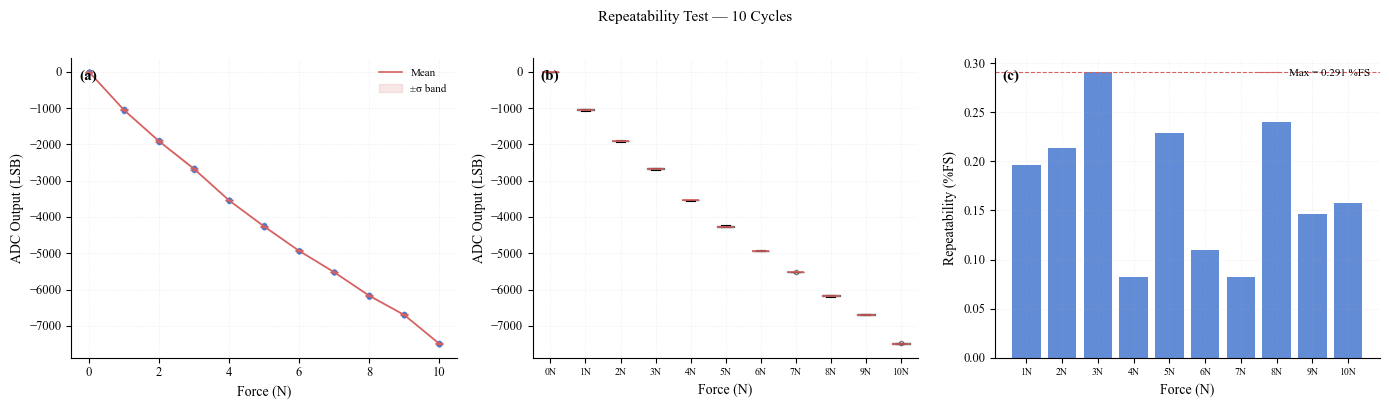

Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test2\png\02a_overlay.png


C:\Users\FangYuxuan\AppData\Local\Temp\ipykernel_14000\3035863621.py:90: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_s.boxplot(box_data, labels=box_labels, patch_artist=True,


Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test2\png\02b_boxplot.png
Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test2\png\02c_repeatability_bar.png


In [9]:
# ── Fig 1: 3-panel repeatability overview ────────────────────────────────────
# (a) 10-cycle overlay + mean ± σ band  (b) box plot  (c) repeatability %FS bar
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

forces_arr = df_results['Force_N'].values
means_arr  = df_results['Mean_LSB'].values
stds_arr   = df_results['Std_LSB'].values

# (a) All individual measurements overlaid + mean ± σ band
ax = axes[0]
for force, files in sorted(repeatability_config.items()):
    meas = []
    for f in files:
        df_tmp = load_sensor_data(f)
        mv, _ = extract_stable_mean(df_tmp)
        meas.append(mv)
    meas = np.array(meas)
    ax.plot(np.full(len(meas), force), meas, "o",
            color=COLORS["blue"], markersize=3, alpha=0.5)

ax.errorbar(forces_arr, means_arr, yerr=stds_arr,
            fmt="none", ecolor=COLORS["red"], capsize=3, elinewidth=0.8)
ax.plot(forces_arr, means_arr, "-", color=COLORS["red"], linewidth=1.2, label="Mean")
ax.fill_between(forces_arr, means_arr - stds_arr, means_arr + stds_arr,
                color=COLORS["red"], alpha=0.15, label="±σ band")
ax.set_xlabel("Force (N)"); ax.set_ylabel("ADC Output (LSB)")
ax.legend(frameon=False, fontsize=8)
add_subplot_label(ax, "(a)")

# (b) Box plot per force level
ax = axes[1]
box_data = []
box_labels = []
for force, files in sorted(repeatability_config.items()):
    meas = []
    for f in files:
        df_tmp = load_sensor_data(f)
        mv, _ = extract_stable_mean(df_tmp)
        meas.append(mv)
    box_data.append(meas)
    box_labels.append(f"{int(force)}N")

bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                medianprops=dict(color=COLORS["red"], linewidth=1.2),
                boxprops=dict(facecolor=COLORS["teal"], alpha=0.6),
                whiskerprops=dict(linewidth=0.8),
                capprops=dict(linewidth=0.8),
                flierprops=dict(marker="o", markersize=3, alpha=0.5))
ax.set_xlabel("Force (N)"); ax.set_ylabel("ADC Output (LSB)")
ax.tick_params(axis="x", labelsize=7)
add_subplot_label(ax, "(b)")

# (c) Repeatability %FS bar chart (non-zero points only)
ax = axes[2]
df_nz = df_results[df_results['Force_N'] > 0].copy()
df_nz['Repeatability_FS_percent'] = df_nz['Std_LSB'] / abs(span) * 100
bar_colors = [COLORS["blue"] if v < 0.5 else COLORS["orange"]
              for v in df_nz['Repeatability_FS_percent']]
ax.bar([f"{int(f)}N" for f in df_nz['Force_N']], df_nz['Repeatability_FS_percent'],
       color=bar_colors, edgecolor="none", alpha=0.85)
ax.axhline(max_repeatability, color=COLORS["red"], linewidth=0.8, linestyle="--",
           label=f"Max = {max_repeatability:.3f} %FS")
ax.set_xlabel("Force (N)"); ax.set_ylabel("Repeatability (%FS)")
ax.legend(frameon=False, fontsize=8)
ax.tick_params(axis="x", labelsize=7)
add_subplot_label(ax, "(c)")

fig.suptitle("Repeatability Test — 10 Cycles", fontsize=11, y=1.01)
plt.tight_layout()
p = save_figure(fig, SAVE_DIR, "02_repeatability_overview")
print(f"Saved: {p}")
plt.show()

# ── Individual sub-figures ────────────────────────────────────────────────────
stems = ["02a_overlay", "02b_boxplot", "02c_repeatability_bar"]
for i, stem in enumerate(stems):
    fig_s, ax_s = plt.subplots(figsize=(5, 4))
    if i == 0:
        for force, files in sorted(repeatability_config.items()):
            meas = [extract_stable_mean(load_sensor_data(f))[0] for f in files]
            ax_s.plot(np.full(len(meas), force), meas, "o",
                      color=COLORS["blue"], markersize=3, alpha=0.5)
        ax_s.errorbar(forces_arr, means_arr, yerr=stds_arr,
                      fmt="none", ecolor=COLORS["red"], capsize=3, elinewidth=0.8)
        ax_s.plot(forces_arr, means_arr, "-", color=COLORS["red"], linewidth=1.2)
        ax_s.fill_between(forces_arr, means_arr - stds_arr, means_arr + stds_arr,
                          color=COLORS["red"], alpha=0.15)
        ax_s.set_xlabel("Force (N)"); ax_s.set_ylabel("ADC Output (LSB)")
    elif i == 1:
        ax_s.boxplot(box_data, labels=box_labels, patch_artist=True,
                     medianprops=dict(color=COLORS["red"], linewidth=1.2),
                     boxprops=dict(facecolor=COLORS["teal"], alpha=0.6),
                     whiskerprops=dict(linewidth=0.8), capprops=dict(linewidth=0.8),
                     flierprops=dict(marker="o", markersize=3, alpha=0.5))
        ax_s.set_xlabel("Force (N)"); ax_s.set_ylabel("ADC Output (LSB)")
        ax_s.tick_params(axis="x", labelsize=7)
    else:
        ax_s.bar([f"{int(f)}N" for f in df_nz['Force_N']], df_nz['Repeatability_FS_percent'],
                 color=bar_colors, edgecolor="none", alpha=0.85)
        ax_s.axhline(max_repeatability, color=COLORS["red"], linewidth=0.8, linestyle="--")
        ax_s.set_xlabel("Force (N)"); ax_s.set_ylabel("Repeatability (%FS)")
        ax_s.tick_params(axis="x", labelsize=7)
    plt.tight_layout()
    p = save_figure(fig_s, SAVE_DIR, stem)
    print(f"Saved: {p}")
    plt.close(fig_s)

#### 8. 零点漂移分析

零点漂移: 0.912 LSB  (0.0122 %FS)


Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test2\png\02_zero_drift.png


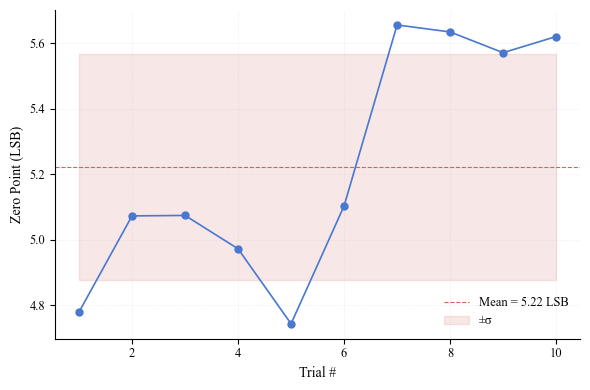

In [10]:
# Zero-point drift across 10 trials
if 0.0 in repeatability_config:
    zero_files = repeatability_config[0.0]
    zero_means = np.array([extract_stable_mean(load_sensor_data(f))[0] for f in zero_files])
    zero_drift = np.max(zero_means) - np.min(zero_means)
    zero_drift_percent = zero_drift / abs(span) * 100

    print(f"零点漂移: {zero_drift:.3f} LSB  ({zero_drift_percent:.4f} %FS)")

    fig_z, ax_z = plt.subplots(figsize=(6, 4))
    ax_z.plot(range(1, len(zero_means)+1), zero_means, "o-",
              color=COLORS["blue"], markersize=5, linewidth=1.2)
    ax_z.axhline(np.mean(zero_means), color=COLORS["red"], linewidth=0.8, linestyle="--",
                 label=f"Mean = {np.mean(zero_means):.2f} LSB")
    ax_z.fill_between(range(1, len(zero_means)+1),
                      np.mean(zero_means) - np.std(zero_means),
                      np.mean(zero_means) + np.std(zero_means),
                      color=COLORS["red"], alpha=0.15, label="±σ")
    ax_z.set_xlabel("Trial #"); ax_z.set_ylabel("Zero Point (LSB)")
    ax_z.legend(frameon=False)
    plt.tight_layout()
    p = save_figure(fig_z, SAVE_DIR, "02_zero_drift")
    print(f"Saved: {p}")
    plt.show()
else:
    zero_drift_percent = 0
    print("注意: 没有0N的数据，跳过零点漂移分析")

#### 9. 各力值点详细测量值分布

Saved: c:\Users\FangYuxuan\Saved Games\Upper_VET6USB\Vet6USB_curve_draw\result_display\test2\png\02_measurements_distribution.png


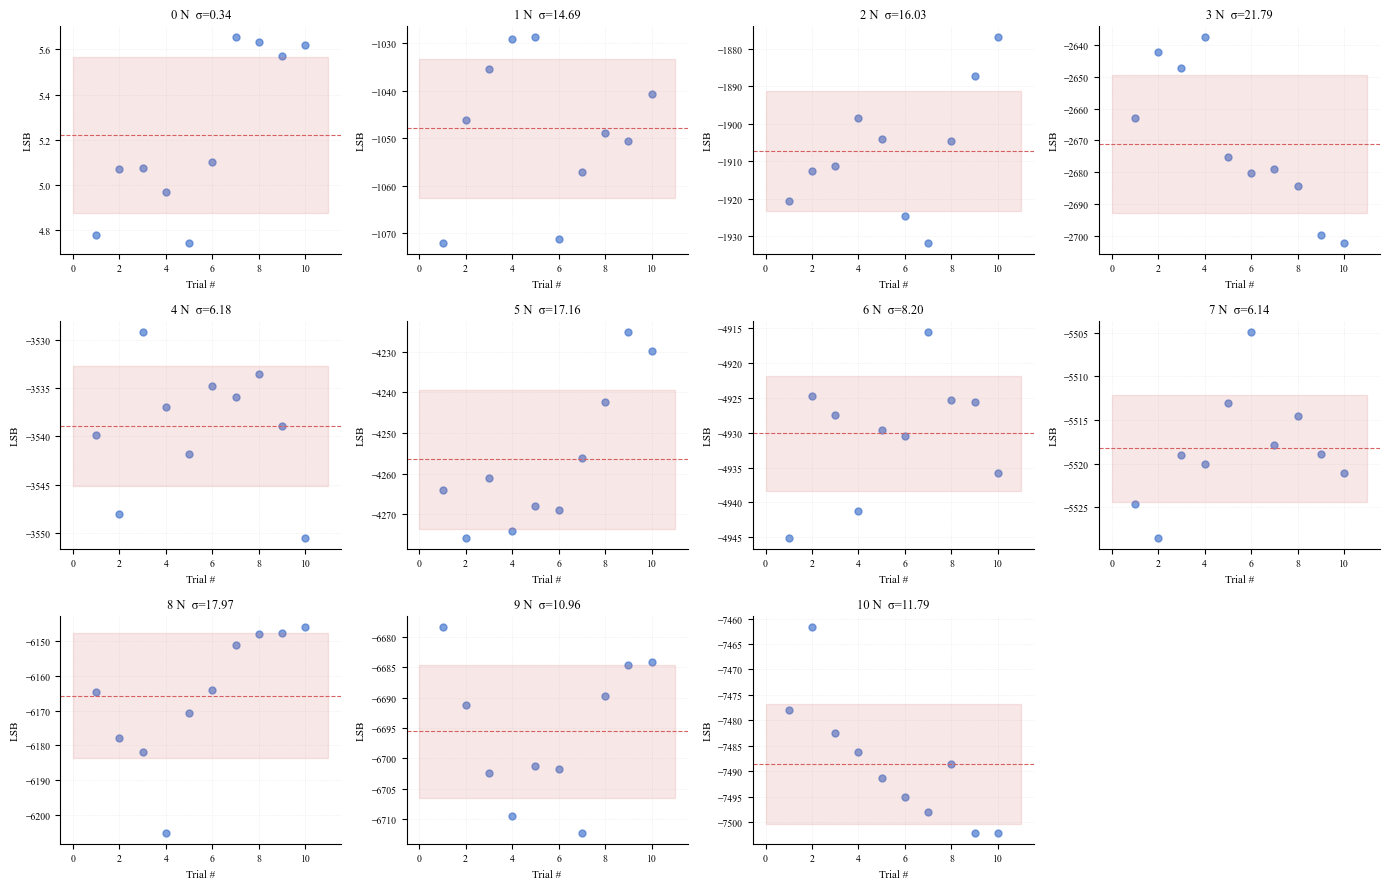

In [11]:
# Per-force scatter distribution (compact grid)
n_forces = len(repeatability_config)
n_cols = min(4, n_forces)
n_rows = (n_forces + n_cols - 1) // n_cols

fig_d, axes_d = plt.subplots(n_rows, n_cols, figsize=(3.5*n_cols, 3*n_rows))
axes_d = np.array(axes_d).reshape(n_rows, n_cols)

for idx, (force, files) in enumerate(sorted(repeatability_config.items())):
    row, col = idx // n_cols, idx % n_cols
    ax = axes_d[row, col]
    meas = np.array([extract_stable_mean(load_sensor_data(f))[0] for f in files])
    ax.scatter(range(1, len(meas)+1), meas, s=25, color=COLORS["blue"], alpha=0.7)
    ax.axhline(np.mean(meas), color=COLORS["red"], linewidth=0.8, linestyle="--")
    ax.fill_between(range(0, len(meas)+2),
                    np.mean(meas) - np.std(meas), np.mean(meas) + np.std(meas),
                    color=COLORS["red"], alpha=0.15)
    ax.set_title(f"{int(force)} N  σ={np.std(meas):.2f}", fontsize=9)
    ax.set_xlabel("Trial #", fontsize=8); ax.set_ylabel("LSB", fontsize=8)
    ax.tick_params(labelsize=7)

for idx in range(n_forces, n_rows * n_cols):
    axes_d[idx // n_cols, idx % n_cols].set_visible(False)

plt.tight_layout()
p = save_figure(fig_d, SAVE_DIR, "02_measurements_distribution")
print(f"Saved: {p}")
plt.show()

#### 10. 结果汇总

In [11]:
# 保存结果
df_results.to_csv('02_repeatability_results.csv', index=False)

print("="*60)
print("【实验02 结果汇总】")
print("="*60)
print(f"""
┌─────────────────────────────────────────────────────────┐
│  重复性测试结果                                         │
├─────────────────────────────────────────────────────────┤
│  测试力值点数:     {len(repeatability_config):>10}                        │
│  量程跨度:         {span:>10.2f} LSB                    │
│  整体重复性:       {max_repeatability:>10.4f} %FS                  │
│  零点漂移:         {zero_drift_percent:>10.4f} %FS                  │
├─────────────────────────────────────────────────────────┤
│  评价标准 (参考):                                       │
│    优秀: < 0.1%FS                                       │
│    良好: 0.1% ~ 0.5%FS                                  │
│    一般: 0.5% ~ 1%FS                                    │
└─────────────────────────────────────────────────────────┘
""")

print("详细结果已保存至: 02_repeatability_results.csv")

【实验02 结果汇总】

┌─────────────────────────────────────────────────────────┐
│  重复性测试结果                                         │
├─────────────────────────────────────────────────────────┤
│  测试力值点数:             11                        │
│  量程跨度:           -7493.79 LSB                    │
│  整体重复性:           0.2907 %FS                  │
│  零点漂移:             0.0122 %FS                  │
├─────────────────────────────────────────────────────────┤
│  评价标准 (参考):                                       │
│    优秀: < 0.1%FS                                       │
│    良好: 0.1% ~ 0.5%FS                                  │
│    一般: 0.5% ~ 1%FS                                    │
└─────────────────────────────────────────────────────────┘

详细结果已保存至: 02_repeatability_results.csv
